# Specialist risk measures: BrownianDistanceVariance and VarianceSkewKurtosis

Some risk measures capture dependence structure or higher-order moment interactions that
variance and CVaR miss. Two such specialist measures are:

  - `BrownianDistanceVariance` — measures non-linear dependence between portfolio
    returns and a reference via the Brownian (distance) covariance framework. It is zero if
    and only if the returns are *statistically independent* of the reference; variance can be
    zero while Brownian Distance Variance is not. It builds a T×T pairwise distance matrix
    so it scales quadratically in observations, not in assets.
  - `VarianceSkewKurtosis` — a composite that combines variance (penalises
    dispersion), negative skewness (penalises asymmetry), and kurtosis (penalises heavy
    tails) into a single objective. It uses large PSD cones so it's best to use a solver that
    supports first-order algorithms such as SCS.

> **When to reach for this**
>
> `BrownianDistanceVariance` is useful when you suspect the return distribution has
> non-linear dependence with a factor or benchmark and want that captured in the
> objective. Reach for `VarianceSkewKurtosis` when the third and fourth moments of the
> portfolio return matter — e.g. when you are allocating into assets with fat tails or
> skewed payoffs and standard mean-variance is blind to the shape of the distribution.

> **Solver compatibility and dataset sizing**
>
> - `BrownianDistanceVariance` builds an O(T²) distance matrix inside the model — the
> number of auxiliary variables grows quadratically with observations. This example uses a
> 50-observation slice to keep the model small.
> - `VarianceSkewKurtosis` requires **SCS** (or another solver that handles polynomial PSD
> cones). It will fail silently or produce wrong results with a continuous-only solver
> like Clarabel. The high-order prior (`HighOrderPriorEstimator`) must also be used, as
> it pre-computes the coskewness and cokurtosis tensors the risk measure needs. This
> example also uses a 50-observation slice for the same reason.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

using CSV, TimeSeries, Clarabel, SCS

## 1. Shared data — 50-observation slice

Both measures in this example use the same short 50-observation slice.
`BrownianDistanceVariance` builds an O(T²) distance matrix, so T is the binding
constraint on model size. `VarianceSkewKurtosis` needs a `HighOrderPriorEstimator`
whose coskewness/cokurtosis computation also scales with T.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 50):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel4, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.85),
              check_sol = (; allow_local = true, allow_almost = true))]

opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 50×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 4-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt ┼ nothing
     sgst ┼ nothing
       tn ┼ nothing
     fees ┼ no

## 2. Brownian Distance Variance

In [3]:
### 2.1 Default formulation

`BrownianDistanceVariance` uses a Norm-1 cone constraint by default
(`NormOneConeBrownianDistanceVariance`). The T×T distance matrix is linearised via
auxiliary variables so Clarabel can handle it as a conic programme.

In [4]:
res_bdvar = optimise(MeanRisk(; r = BrownianDistanceVariance(), opt = opt))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 50×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecis

An alternative formulation (`IneqBrownianDistanceVariance`) uses inequality constraints
rather than a cone. On small problems the results are equivalent; on larger problems the
inequality form may be faster because it avoids a large cone.

In [5]:
res_bdvar_ineq = optimise(MeanRisk(;
                                   r = BrownianDistanceVariance(;
                                                                alg2 = IneqBrownianDistanceVariance()),
                                   opt = opt))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 50×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecis

### 2.2 Alternative formulations

A second formulation switch controls the **rank constraint** used for the distance matrix:
`QuadRiskExpr` (default) or `RSOCRiskExpr`. The latter uses a rotated second-order cone
and can be faster for very dense problems.

In [6]:
res_bdvar_rsoc = optimise(MeanRisk(; r = BrownianDistanceVariance(; alg1 = RSOCRiskExpr()),
                                   opt = opt))

pretty_table(DataFrame(; :assets => rd.nx, :BDVar_default => res_bdvar.w,
                       :BDVar_ineq => res_bdvar_ineq.w, :BDVar_rsoc => res_bdvar_rsoc.w);
             formatters = [resfmt])

┌────────┬───────────────┬────────────┬────────────┐
│ assets │ BDVar_default │ BDVar_ineq │ BDVar_rsoc │
│ String │       Float64 │    Float64 │    Float64 │
├────────┼───────────────┼────────────┼────────────┤
│   AAPL │         0.0 % │      0.0 % │     -0.0 % │
│    AMD │         0.0 % │      0.0 % │     -0.0 % │
│    BAC │         0.0 % │      0.0 % │     -0.0 % │
│    BBY │         0.0 % │      0.0 % │     -0.0 % │
│    CVX │       6.687 % │    6.687 % │    6.687 % │
│     GE │         0.0 % │      0.0 % │     -0.0 % │
│     HD │         0.0 % │      0.0 % │     -0.0 % │
│    JNJ │      43.573 % │   43.573 % │   43.586 % │
│    JPM │         0.0 % │      0.0 % │     -0.0 % │
│     KO │         0.0 % │      0.0 % │     -0.0 % │
│    LLY │         0.0 % │      0.0 % │     -0.0 % │
│    MRK │       4.505 % │    4.506 % │    4.498 % │
│   MSFT │         0.0 % │      0.0 % │     -0.0 % │
│    PEP │       6.377 % │    6.377 % │    6.379 % │
│    PFE │         0.0 % │      0.0 % │     -0

The three formulations produce the same portfolio — the differences are only in how the
conic model is assembled, not in what it optimises.

The composition plot shows that Brownian Distance Variance concentrates into a different
set of names than plain variance minimisation, reflecting its sensitivity to non-linear
dependence rather than just squared-deviation spread.

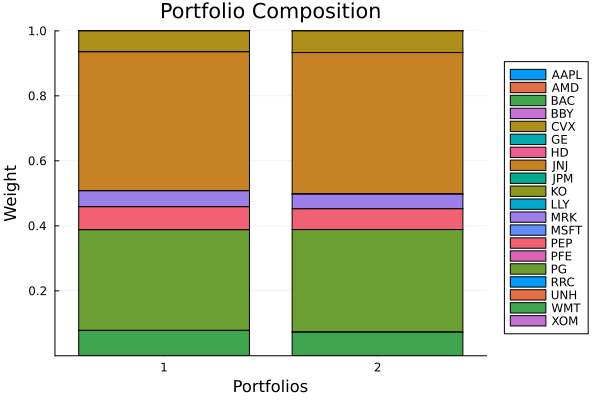

In [7]:
res_var = optimise(MeanRisk(; r = Variance(), opt = opt))

using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_var, res_bdvar], rd)

## 3. VarianceSkewKurtosis

### 3.1 High-order prior and SCS solver

`VarianceSkewKurtosis` requires SCS and a `HighOrderPriorEstimator` prior. We reuse the
same 50-observation slice already loaded in section 1.

In [8]:
pr_ho = prior(HighOrderPriorEstimator(), rd)

scs_slv = Solver(; name = :scs, solver = SCS.Optimizer, settings = "verbose" => false,
                 check_sol = (; allow_local = true, allow_almost = true))
opt_ho = JuMPOptimiser(; pe = pr_ho, slv = scs_slv)

JuMPOptimiser
       pe ┼ HighOrderPrior
          │     pr ┼ LowOrderPrior
          │        │         X ┼ 50×20 Matrix{Float64}
          │        │        mu ┼ 20-element Vector{Float64}
          │        │     sigma ┼ 20×20 Matrix{Float64}
          │        │      chol ┼ nothing
          │        │         w ┼ nothing
          │        │       ens ┼ nothing
          │        │       kld ┼ nothing
          │        │        ow ┼ nothing
          │        │        rr ┼ nothing
          │        │      f_mu ┼ nothing
          │        │   f_sigma ┼ nothing
          │        │       f_w ┴ nothing
          │     kt ┼ 400×400 Matrix{Float64}
          │     D2 ┼ 400×210 SparseArrays.SparseMatrixCSC{Int64, Int64}
          │     L2 ┼ 210×400 SparseArrays.SparseMatrixCSC{Int64, Int64}
          │     S2 ┼ 210×400 SparseArrays.SparseMatrixCSC{Int64, Int64}
          │     sk ┼ 20×400 Matrix{Float64}
          │      V ┼ 20×20 Matrix{Float64}
          │   skmp ┼ MatrixProcessing

### 3.2 Default composite

`VarianceSkewKurtosis` combines three sub-measures:

  - `Variance` — penalises dispersion.
  - `Skewness` (negative skewness convention) — penalises left-skewed returns.
  - `Kurtosis` — penalises fat tails.

The default scales are 1:1:1. Scaling one component higher makes the objective more
sensitive to that moment.

In [9]:
res_vsk = optimise(MeanRisk(; r = VarianceSkewKurtosis(), opt = opt_ho), rd)
println("VarianceSkewKurtosis retcode: $(res_vsk.retcode)")

VarianceSkewKurtosis retcode: OptimisationSuccess
  res ┴ Dict{Any, Any}: Dict{Any, Any}()



### 3.3 Custom component scales

Passing custom `Skewness` and `Kurtosis` with scaled
settings (`MaxRiskMeasureSettings` for skewness and `RiskMeasureSettings` for
kurtosis) lets you control how much each higher-moment penalty
contributes relative to variance.

In [10]:
r_vsk_heavy = VarianceSkewKurtosis(;
                                   sk = Skewness(;
                                                 settings = MaxRiskMeasureSettings(;
                                                                                   scale = 2.0)),
                                   kt = Kurtosis(;
                                                 settings = RiskMeasureSettings(;
                                                                                scale = 2.0)))
res_vsk_heavy = optimise(MeanRisk(; r = r_vsk_heavy, opt = opt_ho), rd)

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ HighOrderPrior
     │           │           │     pr ┼ LowOrderPrior
     │           │           │        │         X ┼ 50×20 Matrix{Float64}
     │           │           │        │        mu ┼ 20-element Vector{Float64}
     │           │           │        │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │        │      chol ┼ nothing
     │           │           │        │         w ┼ nothing
     │           │           │        │       ens ┼ nothing
     │           │           │        │       kld ┼ nothing
     │           │           │        │        ow ┼ nothing
     │           │           │        │        rr ┼ nothing
     │           │           │        │      f_mu ┼ nothing
     │           │           │        │   f_sigma ┼ nothing
     │           │           │        │       f_w ┴ nothin

Compare the two allocations. Heavier skewness/kurtosis penalties push the optimiser further
away from fat-tailed or left-skewed names.

In [11]:
pretty_table(DataFrame(; :assets => rd.nx, :VarianceSkewKurtosis => res_vsk.w,
                       :VSK_heavy_tail => res_vsk_heavy.w); formatters = [resfmt])

┌────────┬──────────────────────┬────────────────┐
│ assets │ VarianceSkewKurtosis │ VSK_heavy_tail │
│ String │              Float64 │        Float64 │
├────────┼──────────────────────┼────────────────┤
│   AAPL │              0.004 % │        0.011 % │
│    AMD │              0.005 % │          0.0 % │
│    BAC │              4.666 % │        4.692 % │
│    BBY │              0.765 % │        0.794 % │
│    CVX │              5.839 % │        5.781 % │
│     GE │              3.994 % │        3.984 % │
│     HD │              1.795 % │        1.857 % │
│    JNJ │              8.999 % │        8.984 % │
│    JPM │              5.485 % │        5.509 % │
│     KO │              6.648 % │        6.649 % │
│    LLY │              7.755 % │        7.764 % │
│    MRK │              9.094 % │        9.064 % │
│   MSFT │              0.755 % │        0.831 % │
│    PEP │              8.311 % │        8.288 % │
│    PFE │              6.668 % │        6.661 % │
│      ⋮ │                    ⋮

### 3.4 Comparison with plain variance (SCS)

We compare the VSK portfolio against a plain minimum-variance portfolio solved with SCS on
the same 50-observation prior, so the only difference is the risk measure.

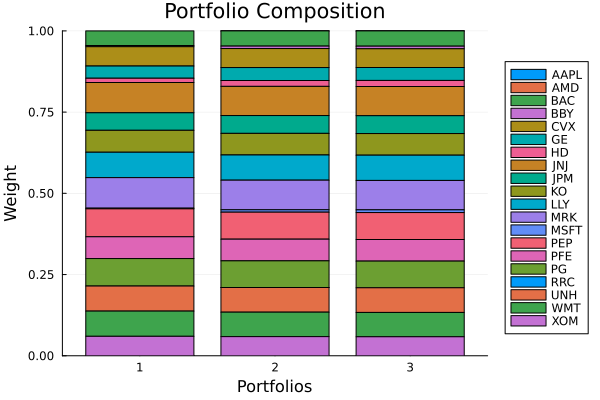

In [12]:
res_var_scs = optimise(MeanRisk(; r = Variance(), opt = opt_ho))

plot_stacked_bar_composition([res_var_scs, res_vsk, res_vsk_heavy], rd)

## Summary

  - `BrownianDistanceVariance` uses a 50-observation slice with Clarabel.
    It captures non-linear dependence via a quadratic T×T distance matrix; keep T small
    (the O(T²) model size is the limiting factor, not the number of assets).
  - `VarianceSkewKurtosis` must use **SCS** (polynomial PSD cones). Pair it with
    `HighOrderPriorEstimator` and a short observation window to keep the
    higher-moment tensor computation feasible.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*